# Calculus in Deep Learning

微积分模块收官：把 7 节课的工具集中到深度学习的核心组件上——激活函数导数、Softmax 与交叉熵、归一化层、梯度消失/爆炸、数值稳定性、期望风险与 mini-batch。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 微积分在深度学习中的全景图


| 深度学习组件 | 微积分工具 | 对应课程 |
|-------------|-----------|---------|
| 反向传播 | 链式法则 / Jacobian 连乘 | 01, 03, 05 |
| 梯度下降 | 导数 / 一阶泰勒 / 曲率 | 01, 04, 06 |
| 激活函数 | 导数公式与饱和分析 | 01 |
| Softmax + 交叉熵 | 商法则 / Jacobian / 对数求导 | 02, 03 |
| 归一化层 | 多元链式法则 | 02 |
| 梯度消失/爆炸 | 链式法则乘积的指数行为 | 01, 03 |
| 数值稳定性 | log-sum-exp / 泰勒近似 | 04 |
| 期望风险 | 积分 / 蒙特卡洛 | 07 |


## 2. 激活函数及其导数


### 2.1 三个核心激活

- **Sigmoid**：$\sigma(x) = \frac{1}{1+e^{-x}}$，用链式法则推导数：$\sigma' = \sigma(1-\sigma)$。**最大值 0.25**（在 $x=0$ 处）——深网逐层乘 $\le 0.25$ 的因子，梯度指数衰减，这是 sigmoid 网络梯度消失的微积分根源。
- **Tanh**：$\tanh' = 1 - \tanh^2$，最大值 1，比 sigmoid 温和。
- **ReLU**：$\mathrm{ReLU}'(x) = \mathbf{1}[x>0]$，分段常数，几乎不衰减梯度——所以现代网络默认用它。

代码画出三者及其导数，并做数值交叉验证：


sigmoid 导数最大值: 0.25 （在 x=0 处，= 0.25）


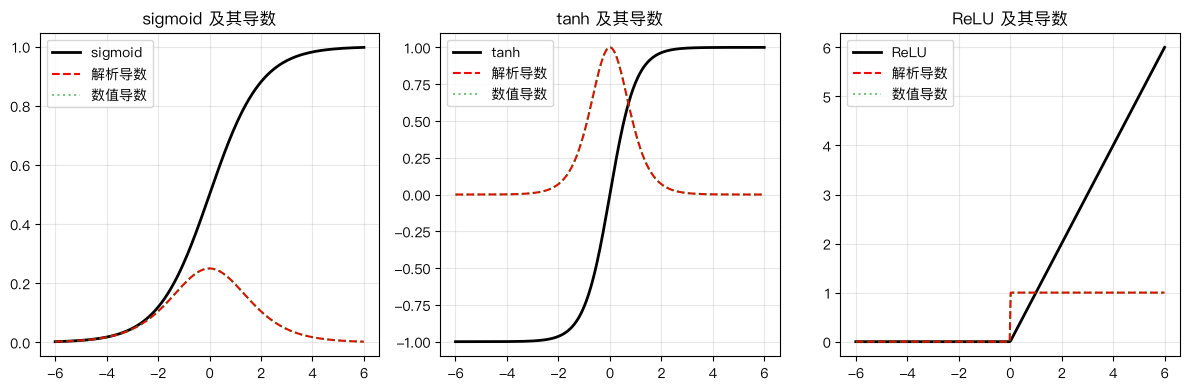

In [2]:
def sigmoid(x): return 1 / (1 + np.exp(-x))

x_vals = np.linspace(-6, 6, 300)
funcs = [
    ('sigmoid', sigmoid, lambda x: sigmoid(x) * (1 - sigmoid(x))),
    ('tanh',    np.tanh, lambda x: 1 - np.tanh(x)**2),
    ('ReLU',    lambda x: np.maximum(0, x), lambda x: (x > 0).astype(float)),
]

plt.figure(figsize=(12, 4))
for i, (name, f, df) in enumerate(funcs):
    ax = plt.subplot(1, 3, i + 1)
    ax.plot(x_vals, f(x_vals), 'k-', linewidth=2, label=name)
    ax.plot(x_vals, df(x_vals), 'r--', label='解析导数')
    ax.plot(x_vals, (f(x_vals+1e-6) - f(x_vals-1e-6)) / 2e-6, 'g:', alpha=0.5, label='数值导数')
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_title(f'{name} 及其导数')
plt.tight_layout()

print("sigmoid 导数最大值:", sigmoid(0)*(1-sigmoid(0)), "（在 x=0 处，= 0.25）")


## 3. Softmax 的 Jacobian


$$s_i = \frac{e^{z_i}}{\sum_k e^{z_k}}$$

用商法则对 $z_j$ 求导，分两种情况：

- $i = j$：$\partial s_i/\partial z_i = s_i(1 - s_i)$（分子分母都依赖 $z_i$）
- $i \ne j$：$\partial s_i/\partial z_j = -s_i s_j$（只有分母依赖 $z_j$）

合起来写成紧凑形式：$\partial s_i/\partial z_j = s_i(\delta_{ij} - s_j)$。数值验证：


In [3]:
def softmax(z):
    e = np.exp(z - z.max())          # 数值稳定（见第 7 节）
    return e / e.sum()

z = np.array([1.0, 2.0, 0.5])
s = softmax(z)
n = len(z)

J_ana = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        J_ana[i, j] = s[i] * ((1.0 if i == j else 0.0) - s[j])

h = 1e-6
J_num = np.zeros((n, n))
for j in range(n):
    zp, zm = z.copy(), z.copy()
    zp[j] += h; zm[j] -= h
    J_num[:, j] = (softmax(zp) - softmax(zm)) / (2*h)

print("解析 Jacobian:\n", np.round(J_ana, 5))
print("最大误差:", np.abs(J_ana - J_num).max())


解析 Jacobian:
 [[ 0.17776 -0.14533 -0.03243]
 [-0.14533  0.23348 -0.08815]
 [-0.03243 -0.08815  0.12058]]
最大误差: 4.841033129920902e-11


## 4. Softmax + 交叉熵：极简梯度


分类损失 $L = -\sum_i y_i \log s_i$（$y$ 为 one-hot 标签）。用链式法则：

$$\frac{\partial L}{\partial z_j} = \sum_i \frac{\partial L}{\partial s_i}\frac{\partial s_i}{\partial z_j} = -\sum_i \frac{y_i}{s_i}\,s_i(\delta_{ij} - s_j) = -\frac{y_j}{s_j} + \sum_i y_i = s_j - y_j$$

（用 $\sum_i y_i = 1$ 消去第二项。）于是 **$\partial L/\partial z = s - y$**——预测与标签的差，漂亮到可以直接背下来。数值验证：


In [4]:
y = np.array([0.0, 1.0, 0.0])     # one-hot 目标
s = softmax(z)

grad_num = np.zeros_like(z)
for j in range(len(z)):
    zp, zm = z.copy(), z.copy()
    zp[j] += h; zm[j] -= h
    Lp = -np.sum(y * np.log(softmax(zp)))
    Lm = -np.sum(y * np.log(softmax(zm)))
    grad_num[j] = (Lp - Lm) / (2*h)

print("∂L/∂z 数值:", np.round(grad_num, 6))
print("∂L/∂z = s−y:", np.round(s - y, 6))
print("最大误差:", np.abs(grad_num - (s - y)).max())


∂L/∂z 数值: [ 0.231224 -0.371468  0.140244]
∂L/∂z = s−y: [ 0.231224 -0.371468  0.140244]
最大误差: 6.556183373973568e-11


## 5. 归一化层：LayerNorm 的导数


LayerNorm 把向量归一化为零均值单位方差：$y = (x - \mu)/\sigma$。这里 $\mu, \sigma$ 都由 $x$ 决定，所以 $\partial y/\partial x$ 不是简单的 $1/\sigma$，而要沿两条链走（直接路径 + 经过 $\mu, \sigma$ 的路径）——这正是多元链式法则（02 课）的用武之地。用 torch 与数值差分对拍：


In [5]:
x = torch.tensor([1.0, 2.0, 3.0, 4.0], dtype=torch.float64, requires_grad=True)
mu = x.mean()
sigma = x.std(unbiased=False)
y = (x - mu) / sigma
w = torch.tensor([1.0, -2.0, 3.0, 0.5], dtype=torch.float64)
L = (y * w).sum()                     # 加权和（避免 Σy ≡ 0 的退化情形）
L.backward()
grad = x.grad.numpy()

xn = x.detach().numpy()
h = 1e-6
grad_num = np.zeros_like(xn)
def ln(v):
    m = v.mean()
    sd = np.sqrt(((v - m)**2).mean())
    return ((v - m) / sd * w.numpy()).sum()
for j in range(len(xn)):
    xp, xm = xn.copy(), xn.copy()
    xp[j] += h; xm[j] -= h
    grad_num[j] = (ln(xp) - ln(xm)) / (2*h)

print("torch 梯度:", np.round(grad, 6))
print("数值梯度 :", np.round(grad_num, 6))
print("最大误差:", np.abs(grad - grad_num).max())


torch 梯度: [ 0.804984 -2.191347  1.96774  -0.581378]
数值梯度 : [ 0.804984 -2.191347  1.96774  -0.581378]
最大误差: 7.409142188663509e-10


## 6. 梯度消失/爆炸的微积分根源


反向传播是**局部导数的连乘**。对 $L$ 关于第 $k$ 层激活 $h_k$ 的梯度：

$$\frac{\partial L}{\partial h_k} = \frac{\partial L}{\partial h_d}\,\prod_{m=k}^{d-1} \underbrace{\frac{\partial h_{m+1}}{\partial h_m}}_{\text{局部 Jacobian}}$$

若每个局部乘子范数 $< 1$，梯度随层数**指数衰减**（消失）；若 $> 1$，**指数爆炸**。tanh 网络的局部乘子含 $\tanh' \le 1$ 与权重范数，深了必然衰减。实证：


Text(0.5, 1.0, '梯度范数随层数指数衰减：梯度消失的实证')

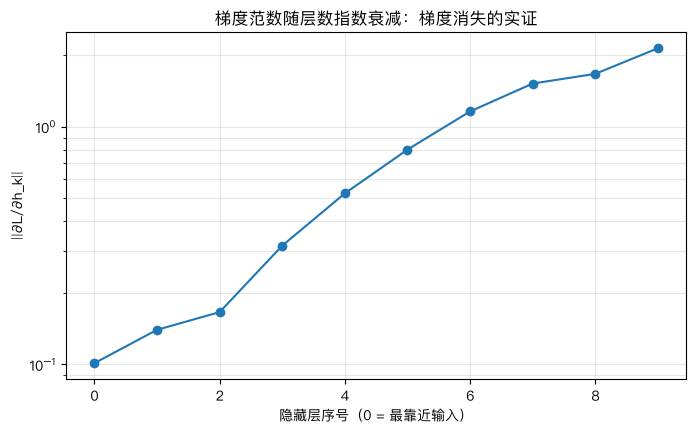

In [6]:
torch.manual_seed(0)
depth = 10
W = torch.randn(depth, 4, 4, dtype=torch.float64) * 0.5
x = torch.randn(4, dtype=torch.float64, requires_grad=True)   # 输入也参与求导
target = torch.randn(4, dtype=torch.float64)

hs = [x]
for k in range(depth):
    hs.append(torch.tanh(W[k] @ hs[-1]))
loss = ((hs[-1] - target)**2).sum()

norms = []
for k in range(depth):
    grad = torch.autograd.grad(loss, hs[k], retain_graph=True)[0]
    norms.append(grad.norm().item())

plt.figure(figsize=(8, 4.5))
plt.plot(range(depth), norms, 'o-')
plt.xlabel('隐藏层序号（0 = 最靠近输入）'); plt.ylabel('‖∂L/∂h_k‖')
plt.yscale('log')
plt.grid(alpha=0.3, which='both')
plt.title('梯度范数随层数指数衰减：梯度消失的实证')


## 7. 数值稳定性：log-sum-exp


$\log\sum_k e^{z_k}$ 直接算会溢出（$e^{1000} = \infty$）。技巧：减去最大值 $m$ 再算，$\log\sum e^{z_k} = m + \log\sum e^{z_k - m}$，因为 $e^{z_k-m} \le 1$ 不会溢出，而最大值项贡献 $\log 1 = 0$ 被 $m$ 找回。Softmax 的减最大值同理。


In [7]:
z_big = np.array([1000.0, 1001.0, 999.0])

with np.errstate(over='ignore'):
    naive = np.log(np.exp(z_big).sum())
print("朴素实现:", naive, "（溢出 → inf）")

m = z_big.max()
stable = m + np.log(np.exp(z_big - m).sum())
print("稳定实现:", stable)
print("解析值  :", 1001 + np.log(1 + np.exp(-1) + np.exp(-2)))


朴素实现: inf （溢出 → inf）
稳定实现: 1001.4076059644444
解析值  : 1001.4076059644444


## 8. 期望风险与 mini-batch（积分视角）


真正的目标是最小化**期望风险** $L_{\text{true}}(w) = \mathbb{E}_{(x,y) \sim P}\,[\ell(x,y;w)]$——一个积分。训练集给不出 $P$，于是用**经验风险**（样本平均）代替，mini-batch 就是它的蒙特卡洛估计（07 课）。代码演示：数据越多，估计的 $w^*$ 越准。


In [8]:
rng = np.random.default_rng(0)
x_all = rng.uniform(-1, 1, 100000)
y_all = 2*x_all + rng.standard_normal(100000) * 0.3

# 最优 w* = E[xy]/E[x²]（最小二乘的解析解）
w_star = np.mean(x_all*y_all) / np.mean(x_all**2)
print(f"全量数据最优 w* = {w_star:.4f}（真实斜率 2.0）")

for bs in [10, 100, 1000]:
    idx = rng.choice(len(x_all), bs, replace=False)
    xb, yb = x_all[idx], y_all[idx]
    w_hat = np.mean(xb*yb) / np.mean(xb**2)
    print(f"batch = {bs:5d}  ŵ = {w_hat:.4f}  误差 = {abs(w_hat - 2.0):.4f}")


全量数据最优 w* = 2.0009（真实斜率 2.0）
batch =    10  ŵ = 2.0613  误差 = 0.0613
batch =   100  ŵ = 1.9040  误差 = 0.0960
batch =  1000  ŵ = 1.9842  误差 = 0.0158


## 总结：微积分模块回顾


| 模块知识链路 | 深度学习中的落点 |
|-------------|----------------|
| 01 导数与求导法则 | 激活函数、损失函数的梯度公式 |
| 02 多元梯度 | 损失曲面、参数更新方向 |
| 03 Jacobian 链式法则 | 反向传播的矩阵本质 |
| 04 Hessian 与曲率 | 牛顿法、条件数、凸性 |
| 05 自动微分 | 训练引擎 autograd |
| 06 梯度下降与优化 | 训练过程本身 |
| 07 积分与概率 | 期望风险、mini-batch |
| 08 综合应用 | 本课全部组件 |

微积分模块完成。下一步进入**概率统计**：用积分语言继续讲分布、似然、信息论——深度学习的另一个数学支柱。


## 课后练习


1. **sigmoid 饱和**：推导 $\sigma'(0) = 0.25$，并解释为什么 10 层 sigmoid 网络的理论梯度上限是 $0.25^{10} \approx 10^{-6}$。
2. **tanh 验证**：数值验证 $\tanh'(x) = 1 - \tanh^2(x)$ 在 $x \in \{-2, 0, 1\}$ 三处成立。
3. **推导 ∂L/∂z = s − y**：写出从 $L = -\sum y_i\log s_i$ 到 $\partial L/\partial z_j = s_j - y_j$ 的完整推导（用 3 节的 Jacobian 公式）。
4. **LayerNorm 梯度**：换一组输入 $x = [2.0, -1.0, 0.5, 3.0]$ 重跑 5 节的验证。
5. **log-sum-exp**：手写一个 `logsumexp` 函数（禁止用 `torch.logsumexp`），用 $z = [1000, 1001, 999]$ 验证，并解释为什么朴素写法会失败。
6. **综合**：从微积分的角度解释残差连接（$h_{k+1} = h_k + f(h_k)$）为什么能缓解梯度消失（提示：$\partial h_{k+1}/\partial h_k = I + J_f$，恒等路径让 Jacobian 连乘不至于指数衰减）。
